# Gurgaon Flat Price Prediction — Model, Insights & Recommender
### Input: `gurgaon_flats_final.csv` (output of `gurgaon_pipeline.ipynb`)

This notebook covers three things:
1. **Price prediction** — regression models trained on Sale listings only (Rent has too
   little data left after outlier removal and lives on a different price scale entirely).
2. **Model insight** — feature importance + SHAP values, so predictions are explainable,
   not just a number out of a black box.
3. **Property recommender** — a preference-based search: a user specifies budget, BHK,
   locality (optional) and other filters, and gets back a ranked list of matches. The
   trained price model doubles as a "fair value" signal, surfacing underpriced listings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb
import shap
import joblib

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

DATA_PATH = '../../data/processed/gurgaon/gurgaon_flats_final.csv'
MODEL_OUT_DIR = '../../app/models'
import os
os.makedirs(MODEL_OUT_DIR, exist_ok=True)


c:\Users\HP\Desktop\machine learning notes\real-estate-capstone\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load & Prepare Modeling Data

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[df['PREFERENCE'] == 'Sale'].copy()
print('Sale listings:', df.shape)
df.head(3)


Sale listings: (7880, 56)


,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,TRANSACT_TYPE_CODE,OWNTYPE_CODE,BHK,BATHROOM_NUM,BALCONY_NUM,FURNISH,FACING_CODE,AGE_CODE,FLOOR_NUM,TOTAL_FLOOR,REGISTER_DATE,PROP_NAME,PRICE,PRICE_SQFT,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,AREA_SQFT,EXPIRY_DATE,CLASS_LABEL,SOCIETY_NAME,BUILDING_NAME,LOCALITY,LATITUDE,LONGITUDE,RERA_STATUS,IS_READY_TO_MOVE,IS_RESALE,IS_RERA,IS_GATED_COMMUNITY,IS_HUDA_APPROVED,FACING_TEXT,USP_COUNT,NEARBY_SHOPPING,NEARBY_EDUCATION,NEARBY_HOSPITAL,NEARBY_METROSTATION,NEARBY_RAILWAYSTATION,NEARBY_CONNECTIVITY,NEARBY_BANK,NEARBY_PARK,TOTAL_NEARBY_LANDMARKS,AMENITIES_COUNT,FEATURES_COUNT,LISTING_DURATION_DAYS,FLOOR_RATIO,IS_GROUND_FLOOR,IS_TOP_FLOOR,PRICE_PER_SQFT_CALC,DIST_FROM_CENTER_KM,LOCALITY_GROUPED,LUXURY_SCORE
0,O71585872,Sale,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,1.0,1,4.0,4,4.0,Semifurnished,1,2,14.0,26.0,2023-09-29,Alpha Corp GurgaonOne 84,26300000,8766.0,3000.0,3434.0,263000.0,3433.995198,2023-11-28,Dealer,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,Sector 84,28.406534,76.962792,RERA,True,True,False,False,False,North,4,4,2,1,0,0,0,1,1,10.0,19,18,60.0,0.538462,False,False,7658.717756,8.579943,Other,22.9
1,T71585466,Sale,"Explore dlf ultima, an upscale ready-To-Move h...",Residential Apartment,1.0,1,4.0,4,3.0,Semifurnished,1,1,7.0,29.0,2023-09-29,DLF The Ultima,36000000,21176.0,1700.0,2870.0,1.0,2869.995987,2023-11-28,Dealer,DLF The Ultima,DLF The Ultima,Sector 81,28.388907,76.951328,RERA,True,True,True,False,False,North,4,1,2,1,1,1,2,0,0,9.0,25,22,60.0,0.241379,False,False,12543.571547,10.760970,Sector 81,26.6
2,I71493958,Sale,Looking for a 3 bhk property for purchase in g...,Residential Apartment,1.0,1,3.0,3,3.0,Semifurnished,0,1,14.0,28.0,2023-09-23,Experion Windchants,38500000,13740.0,1600.0,2802.0,1.0,2801.996082,2023-11-22,Dealer,Experion Windchants,Experion Windchants,Sector 112,28.518677,77.015115,RERA,True,True,True,False,False,Unknown,4,1,2,2,0,1,1,0,0,8.0,19,17,60.0,0.500000,False,False,13740.204795,6.675226,Other,21.6


In [3]:
# Columns that are IDs, free text, dates, or constants -- not useful as model inputs.
NON_FEATURE_COLS = [
    'PROP_ID', 'DESCRIPTION', 'PREFERENCE', 'PROP_NAME', 'SOCIETY_NAME', 'BUILDING_NAME',
    'CLASS_LABEL', 'REGISTER_DATE', 'EXPIRY_DATE', 'RERA_STATUS',  # RERA_STATUS constant for Sale
    'LOCALITY',  # superseded by LOCALITY_GROUPED
    'PRICE_PER_SQFT_CALC', 'PRICE_SQFT',  # would leak PRICE directly (PRICE = PRICE_SQFT * AREA_SQFT)
]

TARGET = 'PRICE'
feature_df = df.drop(columns=[c for c in NON_FEATURE_COLS if c in df.columns])
print('Feature columns:', feature_df.shape[1] - 1)
feature_df.dtypes


Feature columns: 42


PROPERTY_TYPE                 str
TRANSACT_TYPE_CODE            str
OWNTYPE_CODE                int64
BHK                       float64
BATHROOM_NUM                int64
BALCONY_NUM               float64
FURNISH                       str
FACING_CODE                 int64
AGE_CODE                    int64
FLOOR_NUM                 float64
TOTAL_FLOOR               float64
PRICE                       int64
CARPET_SQFT               float64
SUPERBUILTUP_SQFT         float64
BROKERAGE                 float64
AREA_SQFT                 float64
LATITUDE                  float64
LONGITUDE                 float64
IS_READY_TO_MOVE             bool
IS_RESALE                    bool
IS_RERA                      bool
IS_GATED_COMMUNITY           bool
IS_HUDA_APPROVED             bool
FACING_TEXT                   str
USP_COUNT                   int64
NEARBY_SHOPPING             int64
NEARBY_EDUCATION            int64
NEARBY_HOSPITAL             int64
NEARBY_METROSTATION         int64
NEARBY_RAILWAY

**Leakage note:** `PRICE_SQFT` and the recomputed `PRICE_PER_SQFT_CALC` are dropped from
the feature set. Both are almost perfectly `PRICE / AREA_SQFT`, so keeping either would let
the model "predict" price by just multiplying it back out — that's leakage, not learning.


In [4]:
CATEGORICAL_COLS = [
    'PROPERTY_TYPE', 'FURNISH', 'LOCALITY_GROUPED', 'FACING_CODE', 'AGE_CODE',
    'OWNTYPE_CODE', 'TRANSACT_TYPE_CODE', 'FACING_TEXT',
]
BOOLEAN_COLS = [
    'IS_READY_TO_MOVE', 'IS_RESALE', 'IS_RERA', 'IS_GATED_COMMUNITY', 'IS_HUDA_APPROVED',
    'IS_GROUND_FLOOR', 'IS_TOP_FLOOR',
]
NUMERIC_COLS = [c for c in feature_df.columns
                if c not in CATEGORICAL_COLS + BOOLEAN_COLS + [TARGET]]

print(f'{len(CATEGORICAL_COLS)} categorical, {len(BOOLEAN_COLS)} boolean, {len(NUMERIC_COLS)} numeric')
print(NUMERIC_COLS)


8 categorical, 7 boolean, 27 numeric
['BHK', 'BATHROOM_NUM', 'BALCONY_NUM', 'FLOOR_NUM', 'TOTAL_FLOOR', 'CARPET_SQFT', 'SUPERBUILTUP_SQFT', 'BROKERAGE', 'AREA_SQFT', 'LATITUDE', 'LONGITUDE', 'USP_COUNT', 'NEARBY_SHOPPING', 'NEARBY_EDUCATION', 'NEARBY_HOSPITAL', 'NEARBY_METROSTATION', 'NEARBY_RAILWAYSTATION', 'NEARBY_CONNECTIVITY', 'NEARBY_BANK', 'NEARBY_PARK', 'TOTAL_NEARBY_LANDMARKS', 'AMENITIES_COUNT', 'FEATURES_COUNT', 'LISTING_DURATION_DAYS', 'FLOOR_RATIO', 'DIST_FROM_CENTER_KM', 'LUXURY_SCORE']


In [5]:
for c in BOOLEAN_COLS:
    feature_df[c] = feature_df[c].astype(int)

X = feature_df.drop(columns=[TARGET])
y = feature_df[TARGET]

# Price is heavily right-skewed (crores, long tail) -- model log(price), not raw price.
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' Test:', X_test.shape)


Train: (6304, 42)  Test: (1576, 42)


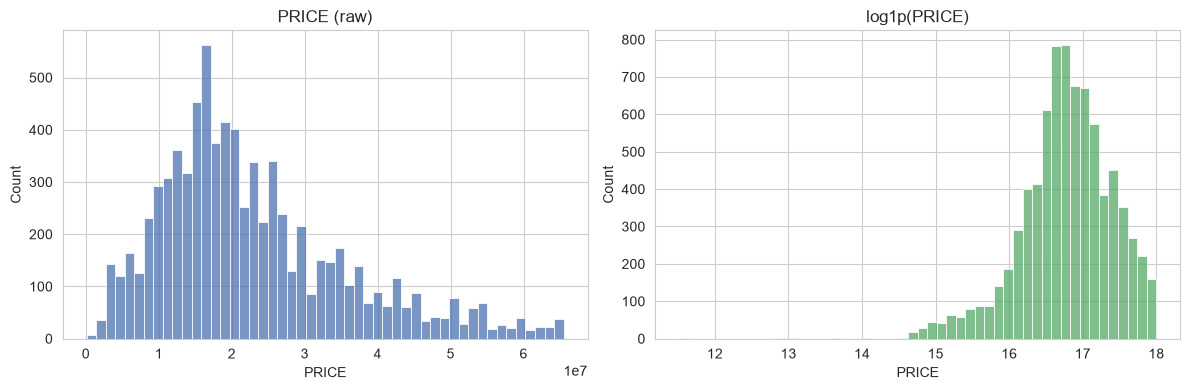

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('PRICE (raw)')
sns.histplot(y_log, bins=50, ax=axes[1], color='#55A868')
axes[1].set_title('log1p(PRICE)')
plt.tight_layout()
plt.show()


## 2. Preprocessing Pipeline

One-hot encoding for categoricals, passthrough for numeric/boolean. Wrapped in a
`ColumnTransformer` + `Pipeline` so the exact same transform can be reused later for the
recommender and for scoring new listings — no risk of train/inference skew.


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS),
    ],
    remainder='passthrough',  # numeric + boolean columns pass through unchanged
)

# Fit once here so we can inspect the expanded feature names for the SHAP section later.
preprocessor.fit(X_train)
encoded_feature_names = (
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS))
    + [c for c in X_train.columns if c not in CATEGORICAL_COLS]
)
print(f'{X_train.shape[1]} raw columns -> {len(encoded_feature_names)} encoded columns')


42 raw columns -> 98 encoded columns


## 3. Model Comparison

Three models, increasing in complexity: Linear Regression (baseline), Random Forest, and
XGBoost. All trained on `log1p(PRICE)`; metrics below are reported back in real rupees
(`np.expm1` inverts the log) so MAE/RMSE are directly interpretable as "average rupee
error", not "average log-rupee error".


In [8]:
def evaluate(model, X_tr, y_tr_log, X_te, y_te_raw, name):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_tr, y_tr_log)
    pred_log = pipe.predict(X_te)
    pred = np.expm1(pred_log)

    r2 = r2_score(y_te_raw, pred)
    mae = mean_absolute_error(y_te_raw, pred)
    rmse = np.sqrt(mean_squared_error(y_te_raw, pred))
    mape = np.mean(np.abs((y_te_raw - pred) / y_te_raw)) * 100

    print(f'{name:20s}  R2={r2:.4f}  MAE=₹{mae:,.0f}  RMSE=₹{rmse:,.0f}  MAPE={mape:.2f}%')
    return pipe, {'model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []
pipe_lr, r = evaluate(LinearRegression(), X_train, y_train_log, X_test, y_test, 'Linear Regression')
results.append(r)
pipe_ridge, r = evaluate(Ridge(alpha=1.0), X_train, y_train_log, X_test, y_test, 'Ridge')
results.append(r)
pipe_rf, r = evaluate(RandomForestRegressor(n_estimators=300, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1),
                       X_train, y_train_log, X_test, y_test, 'Random Forest')
results.append(r)
pipe_xgb, r = evaluate(xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE),
                        X_train, y_train_log, X_test, y_test, 'XGBoost')
results.append(r)

results_df = pd.DataFrame(results).set_index('model')
results_df


Linear Regression     R2=0.5947  MAE=₹5,562,176  RMSE=₹8,074,128  MAPE=27.29%
Ridge                 R2=0.7321  MAE=₹4,465,938  RMSE=₹6,564,415  MAPE=22.70%
Random Forest         R2=0.8882  MAE=₹2,539,870  RMSE=₹4,239,798  MAPE=12.44%
XGBoost               R2=0.8965  MAE=₹2,470,554  RMSE=₹4,080,469  MAPE=11.84%


,R2,MAE,RMSE,MAPE
model,,,,
Linear Regression,0.594704,5.562176e+06,8.074128e+06,27.293587
Ridge,0.732100,4.465938e+06,6.564415e+06,22.695109
Random Forest,0.888244,2.539870e+06,4.239798e+06,12.436340
XGBoost,0.896486,2.470554e+06,4.080469e+06,11.844116


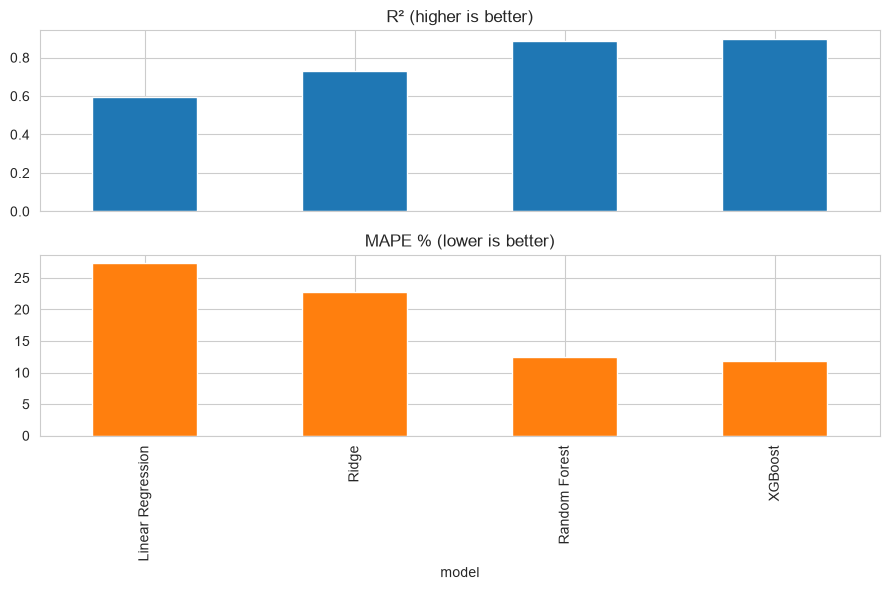

In [9]:
results_df[['R2', 'MAPE']].plot(kind='bar', subplots=True, figsize=(9, 6), legend=False,
                                 title=['R² (higher is better)', 'MAPE % (lower is better)'])
plt.tight_layout()
plt.show()


Pick whichever model wins on the metrics above — usually XGBoost or Random Forest for
this kind of tabular data with mixed categorical/numeric features and non-linear price
behavior (e.g. luxury premiums, locality effects). The rest of the notebook assumes
**XGBoost is the winner**; if Random Forest scores better for you, just swap
`best_pipe = pipe_xgb` for `best_pipe = pipe_rf` below.


In [10]:
best_pipe = pipe_xgb  # <- change this if a different model wins on your run
best_name = 'XGBoost'


## 4. Light Hyperparameter Tuning

A small randomized search around the winning model — not exhaustive, just enough to
squeeze a bit more performance without an expensive grid search.


In [11]:
param_dist = {
    'model__n_estimators': [200, 300, 400, 600],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

tuning_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(random_state=RANDOM_STATE)),
])

search = RandomizedSearchCV(
    tuning_pipe, param_dist, n_iter=20, cv=5, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train_log)
print('Best CV R2:', search.best_score_)
print('Best params:', search.best_params_)

best_pipe = search.best_estimator_
pred = np.expm1(best_pipe.predict(X_test))
print(f"Test R2={r2_score(y_test, pred):.4f}  MAE=₹{mean_absolute_error(y_test, pred):,.0f}  "
      f"MAPE={np.mean(np.abs((y_test - pred) / y_test)) * 100:.2f}%")


Best CV R2: 0.9091602683269642
Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Test R2=0.9020  MAE=₹2,361,315  MAPE=11.27%


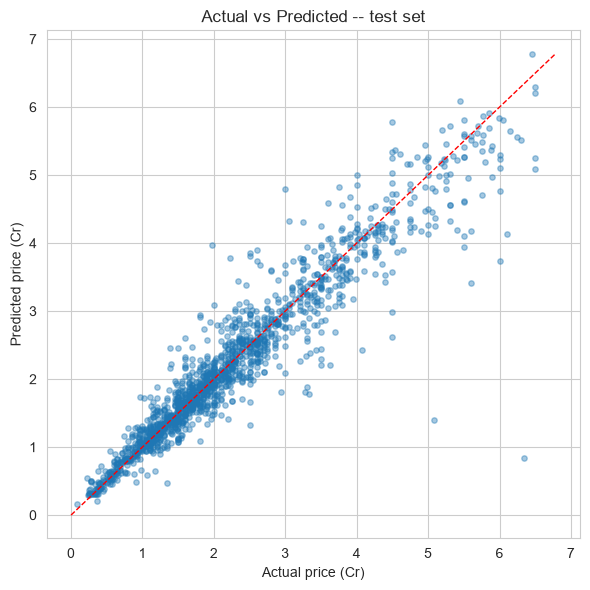

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test / 1e7, pred / 1e7, alpha=0.4, s=15)
lims = [0, max(y_test.max(), pred.max()) / 1e7]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Actual price (Cr)')
plt.ylabel('Predicted price (Cr)')
plt.title('Actual vs Predicted -- test set')
plt.tight_layout()
plt.show()


## 5. Model Insight: Feature Importance + SHAP

Two views:
- **Global importance** (XGBoost's built-in gain-based importance) — which features
  matter *on average* across all predictions.
- **SHAP values** — for every prediction, how much each feature pushed the price up or
  down relative to the average, including direction (not just magnitude) and interactions.
  This is what lets you explain a *specific* prediction, not just the model overall.


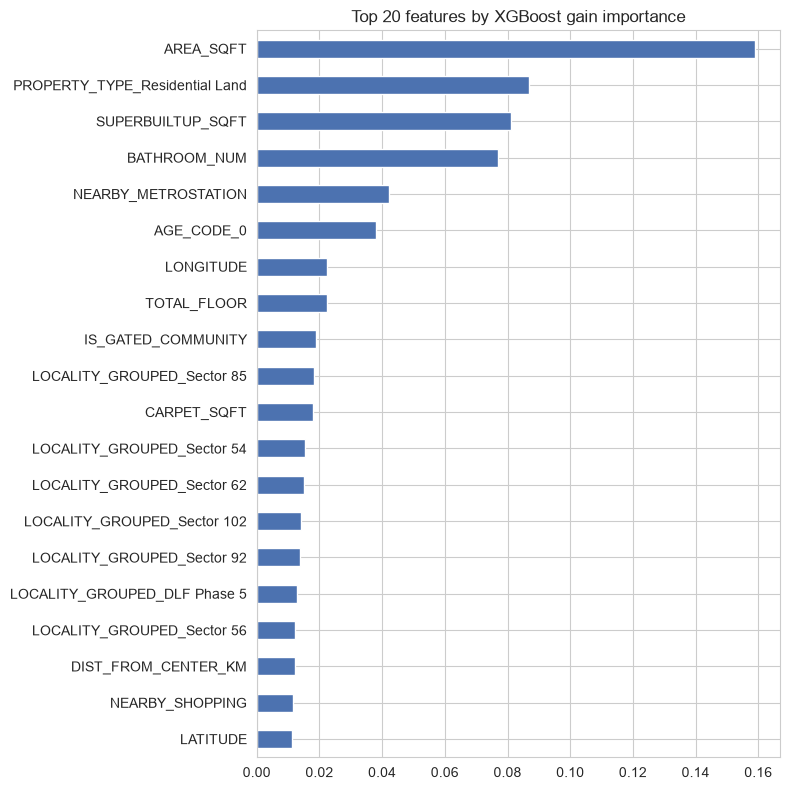

In [13]:
model = best_pipe.named_steps['model']
importances = pd.Series(model.feature_importances_, index=encoded_feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 8))
top20[::-1].plot(kind='barh', color='#4C72B0')
plt.title('Top 20 features by XGBoost gain importance')
plt.tight_layout()
plt.show()


In [14]:
# SHAP needs the already-encoded matrix, not the raw dataframe
X_test_encoded = pd.DataFrame(preprocessor.transform(X_test), columns=encoded_feature_names, index=X_test.index)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_encoded)


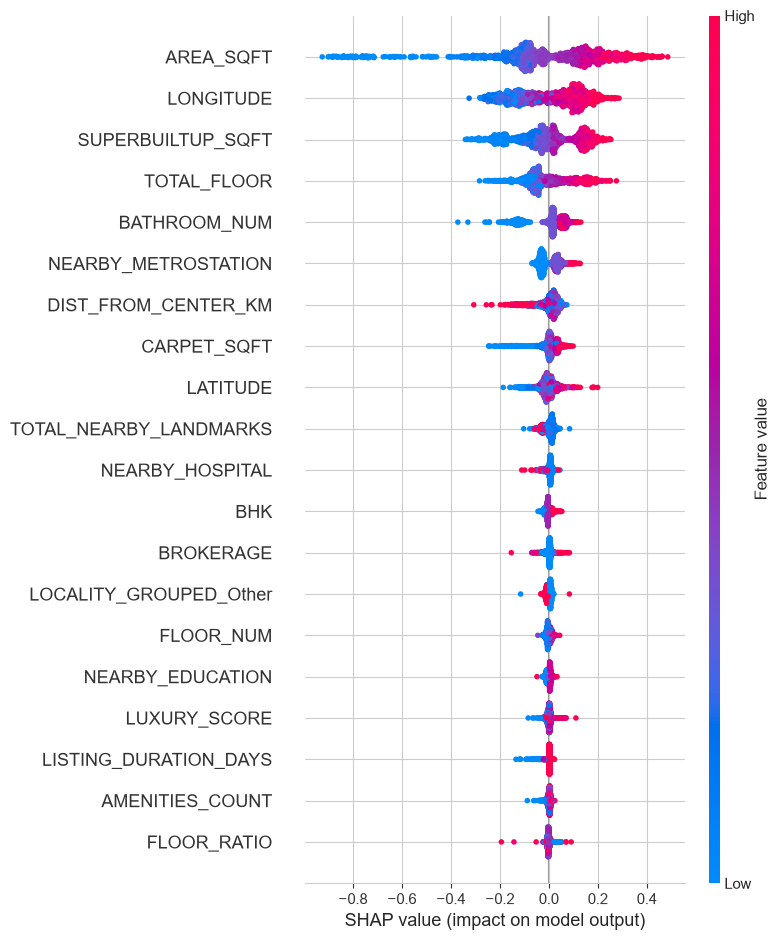

In [15]:
shap.summary_plot(shap_values, X_test_encoded, max_display=20, show=False)
plt.tight_layout()
plt.show()


The summary plot above is the single most useful chart in this section: each dot is one
listing, color shows the feature's value (red=high, blue=low), and horizontal position
shows how much that feature pushed the prediction up or down. E.g. if `AREA_SQFT` dots are
mostly red-on-the-right / blue-on-the-left, bigger flats reliably push price up, as expected.


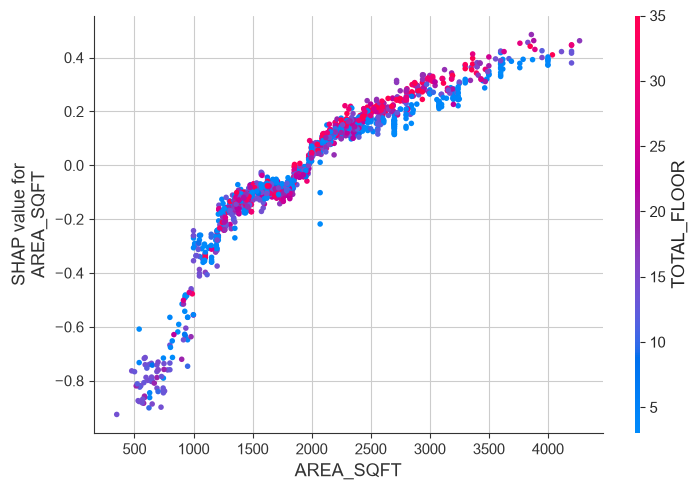

In [16]:
# Dependence plot for the single most important feature -- shows the actual relationship
# shape (not just "it matters"), and whether it interacts with another feature.
top_feature = importances.idxmax()
shap.dependence_plot(top_feature, shap_values, X_test_encoded, show=False)
plt.tight_layout()
plt.show()


Listing index 1406:  actual=₹39,000,000  predicted=₹40,873,768


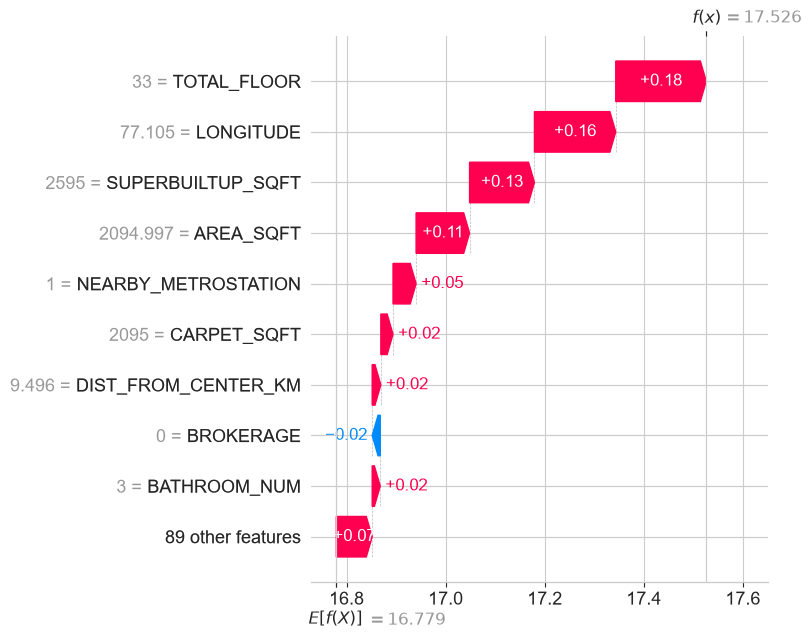

In [17]:
# Explain one individual prediction -- e.g. the first test-set listing.
i = 0
print(f"Listing index {X_test.index[i]}:  actual=₹{y_test.iloc[i]:,.0f}  predicted=₹{pred[i]:,.0f}")
shap.plots.waterfall(
    shap.Explanation(values=shap_values[i], base_values=explainer.expected_value,
                      data=X_test_encoded.iloc[i], feature_names=encoded_feature_names),
    show=False,
)
plt.tight_layout()
plt.show()


In [18]:
# Save the trained pipeline (preprocessing + model together) for reuse in the recommender
# section below, and for a future inference script/API.
joblib.dump(best_pipe, f'{MODEL_OUT_DIR}/gurgaon_price_model.joblib')
print(f'Model saved to {MODEL_OUT_DIR}/gurgaon_price_model.joblib')


Model saved to ../../app/models/gurgaon_price_model.joblib


## 6. Property Recommender (Preference-Based Search)

A user supplies a **budget range**, **BHK**, and optionally a **locality** and other soft
preferences (furnishing, gated community, minimum amenities). The function:

1. **Hard-filters** the dataset on the required constraints (budget, BHK, locality if given).
2. Scores every remaining candidate with the trained price model to get a **fair-value
   estimate** — `(predicted_price - actual_price) / predicted_price` — positive means the
   listing is priced *below* what the model expects for a property with those features,
   i.e. a potential good deal.
3. Combines the value score with the listing's `LUXURY_SCORE` and proximity to the city
   center into one ranking score, and returns the top N.


In [19]:
def score_candidates(candidates: pd.DataFrame) -> pd.Series:
    """Fair-value score: (predicted - actual) / predicted, using the trained price model."""
    cand_features = candidates.drop(columns=[c for c in NON_FEATURE_COLS if c in candidates.columns])
    cand_features = cand_features.drop(columns=[TARGET])
    for c in BOOLEAN_COLS:
        cand_features[c] = cand_features[c].astype(int)

    pred_log = best_pipe.predict(cand_features)
    predicted_price = np.expm1(pred_log)
    value_score = (predicted_price - candidates['PRICE']) / predicted_price
    return value_score, predicted_price


def recommend_properties(
    df: pd.DataFrame,
    budget_min: float,
    budget_max: float,
    bhk: int | None = None,
    locality: str | None = None,
    furnish: str | None = None,
    gated_only: bool = False,
    min_amenities: int | None = None,
    top_n: int = 10,
    weights: dict | None = None,
) -> pd.DataFrame:
    """Preference-based property search over Sale listings.

    Parameters
    ----------
    budget_min, budget_max : rupee range the user is willing to spend
    bhk : exact BHK match if given, otherwise any
    locality : must match LOCALITY_GROUPED (case-insensitive substring) if given
    furnish : 'Furnished' / 'Semifurnished' / 'Unfurnished' if given
    gated_only : only return gated-community listings
    min_amenities : minimum AMENITIES_COUNT
    top_n : how many results to return
    weights : override the default ranking weights, e.g. {'value': 0.6, 'luxury': 0.3, 'distance': 0.1}
    """
    weights = weights or {'value': 0.5, 'luxury': 0.3, 'distance': 0.2}

    candidates = df[(df['PREFERENCE'] == 'Sale') &
                     (df['PRICE'].between(budget_min, budget_max))].copy()

    if bhk is not None:
        candidates = candidates[candidates['BHK'] == bhk]
    if locality is not None:
        candidates = candidates[candidates['LOCALITY_GROUPED'].str.contains(locality, case=False, na=False)]
    if furnish is not None:
        candidates = candidates[candidates['FURNISH'] == furnish]
    if gated_only:
        candidates = candidates[candidates['IS_GATED_COMMUNITY']]
    if min_amenities is not None:
        candidates = candidates[candidates['AMENITIES_COUNT'] >= min_amenities]

    if candidates.empty:
        print('No listings match those filters -- try widening the budget or dropping a constraint.')
        return candidates

    value_score, predicted_price = score_candidates(candidates)
    candidates = candidates.assign(PREDICTED_PRICE=predicted_price, VALUE_SCORE=value_score)

    # Normalize each ranking input to 0-1 so the weights are comparable
    def norm(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)

    rank_score = (
        weights['value'] * norm(candidates['VALUE_SCORE'])
        + weights['luxury'] * norm(candidates['LUXURY_SCORE'])
        + weights['distance'] * (1 - norm(candidates['DIST_FROM_CENTER_KM']))  # closer = better
    )
    candidates = candidates.assign(RANK_SCORE=rank_score)

    cols = ['SOCIETY_NAME', 'LOCALITY_GROUPED', 'PROPERTY_TYPE', 'BHK', 'AREA_SQFT',
            'PRICE', 'PREDICTED_PRICE', 'VALUE_SCORE', 'LUXURY_SCORE',
            'DIST_FROM_CENTER_KM', 'FURNISH', 'RANK_SCORE']
    return candidates.sort_values('RANK_SCORE', ascending=False)[cols].head(top_n).reset_index(drop=True)


In [20]:
# Example: a buyer with a 1.5-2 Cr budget, wants a 3 BHK, prefers the Sector 65 area
# Note: IS_GATED_COMMUNITY is true for only 9/7312 listings in this dataset (the site rarely
# tags it), so it's a usable filter but will empty out results fast if combined with other
# tight constraints -- worth surfacing as an optional toggle in a UI rather than a default-on filter.
recommend_properties(
    df, budget_min=1.5e7, budget_max=2.0e7, bhk=3, locality='Sector 65', top_n=10,
)


,SOCIETY_NAME,LOCALITY_GROUPED,PROPERTY_TYPE,BHK,AREA_SQFT,PRICE,PREDICTED_PRICE,VALUE_SCORE,LUXURY_SCORE,DIST_FROM_CENTER_KM,FURNISH,RANK_SCORE
0,Emaar Emerald Hills,Sector 65,Residential Apartment,3.0,1394.998049,19000000,20694032.0,0.081861,35.3,7.173179,Semifurnished,0.783770
1,Emaar Emerald Hills,Sector 65,Independent/Builder Floor,3.0,1999.997203,18500000,23382016.0,0.208794,16.9,7.173179,Semifurnished,0.722613
2,Emaar Emerald Hills,Sector 65,Independent/Builder Floor,3.0,1379.998070,18000000,21116156.0,0.147572,17.7,7.173179,Semifurnished,0.630383
3,Emaar MGF Emerald Estate,Sector 65,Residential Apartment,3.0,1349.998112,18000000,19386996.0,0.071543,27.7,7.384981,Semifurnished,0.605350
4,Emaar MGF Emerald Floors Premier,Sector 65,Residential Apartment,3.0,1649.997693,20000000,22168408.0,0.097815,24.6,7.384981,Semifurnished,0.603372
5,Unknown,Sector 65,Independent/Builder Floor,3.0,1249.998252,20000000,19915116.0,-0.004262,33.7,7.384981,Semifurnished,0.566669
6,Emaar Mgf Emerald Floors,Sector 65,Independent/Builder Floor,3.0,1379.998070,20000000,19333232.0,-0.034488,32.6,7.309928,Semifurnished,0.514992
7,Emaar MGF Emerald Estate,Sector 65,Residential Apartment,3.0,1394.998049,19000000,19602324.0,0.030727,33.1,8.088688,Semifurnished,0.463498
8,M3M Polo Suites,Sector 65,Residential Apartment,3.0,3979.994435,20000000,23118820.0,0.134904,15.4,7.691566,Semifurnished,0.460883
9,Emaar MGF Emerald Estate,Sector 65,Residential Apartment,3.0,1349.998112,19500000,19599368.0,0.005070,30.1,8.088688,Semifurnished,0.374565


In [21]:
# Example: no locality preference, wider budget, just wants the best value 4 BHKs
recommend_properties(
    df, budget_min=2e7, budget_max=4e7, bhk=4, top_n=10,
    weights={'value': 0.7, 'luxury': 0.2, 'distance': 0.1},
)


,SOCIETY_NAME,LOCALITY_GROUPED,PROPERTY_TYPE,BHK,AREA_SQFT,PRICE,PREDICTED_PRICE,VALUE_SCORE,LUXURY_SCORE,DIST_FROM_CENTER_KM,FURNISH,RANK_SCORE
0,South city 1,Other,Independent/Builder Floor,4.0,3499.995106,25000000,38526244.0,0.351092,52.8,3.876138,Furnished,0.933801
1,AWHO Sispal Vihar,Sector 49,Residential Apartment,4.0,3599.994966,25000000,38141220.0,0.344541,43.8,5.065168,Semifurnished,0.890637
2,ARJUN MARG,DLF Phase 1,Independent/Builder Floor,4.0,2999.995805,30000000,47927944.0,0.374060,35.2,6.334960,Semifurnished,0.868326
3,Unknown,Other,Independent/Builder Floor,4.0,3761.994740,26500000,36755620.0,0.279022,47.0,5.085893,Semifurnished,0.867274
4,NUL,DLF Phase 2,Independent/Builder Floor,4.0,2699.996225,26000000,37383532.0,0.304507,43.8,6.723158,Unfurnished,0.862179
5,New Era Home sector 43,Other,Residential Apartment,4.0,3249.995456,26000000,38997112.0,0.333284,36.1,6.481699,Semifurnished,0.849025
6,Suncity Essel Towers,Other,Residential Apartment,4.0,3409.995232,37500000,48209044.0,0.222138,50.1,5.737275,Semifurnished,0.845687
7,Unknown,Other,Independent/Builder Floor,4.0,2159.996980,21000000,25672872.0,0.182016,48.7,5.257308,Semifurnished,0.820366
8,Godrej Meridien,Sector 106,Residential Apartment,4.0,2719.996197,22200000,37762780.0,0.412120,17.8,6.683682,Semifurnished,0.820325
9,Mayfield Gardens,Other,Independent/Builder Floor,4.0,2699.996225,20000000,24472008.0,0.182740,48.0,5.197061,Semifurnished,0.818294


## Summary

- **Price model:** XGBoost (tuned) trained on `log1p(PRICE)` with one-hot encoded
  categoricals — evaluate the metrics table in Section 3/4 on your own run to confirm it's
  still the best of the three.
- **Insight:** global feature importance + SHAP summary/dependence/waterfall plots explain
  both what matters on average and why any single prediction came out the way it did.
- **Recommender:** `recommend_properties()` in Section 6 does hard-filtering on user
  constraints, then ranks by a blend of model-estimated fair value, luxury score, and
  proximity to the city center. Tune the `weights` dict per user or expose it as a UI control.
- **Saved artifact:** `gurgaon_price_model.joblib` — load with `joblib.load(...)` to reuse
  the exact fitted preprocessing + model pipeline in a script or API without retraining.

**Natural next steps:** wire `recommend_properties()` into an API endpoint (FastAPI/Flask)
for `ml-service`, add pagination/more filters (age of property, floor preference), and
consider retraining periodically as new scraped listings come in.
